# **7. ML - Clustering**

In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message="All reachability values are inf. Set a larger max_eps or all data will be considered outliers."
)

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, OPTICS, estimate_bandwidth
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap
import joblib

2025-04-09 22:43:23.051115: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-09 22:43:23.244233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744231403.314487    1319 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744231403.337342    1319 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744231403.496492    1319 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Cargar el archivo CSV
df = pd.read_csv('../data/processed/campana_marketing.csv', parse_dates=['Dt_Customer'])

# Convertir la columna 'Income' de float64 a int64
df['Income'] = df['Income'].astype('int64')

## Selección de variables útiles para clustering
### Variables candidatas para ser eliminadas:
- **`ID`**: identificador inútil para clustering.
- **`Dt_Customer`**: además de que es de tipo datetime, ya creamos `Days` y `Seniority` que lo resumen.
- **`Year_Birth`**: ya tenemos `Age`, que es más útil y comprensible.
- **De `AcceptedCmp1` a `AcceptedCmp5`**: ya lo hemos resumido con `AcceptedCmp`.
- **`Response`**: está relacionado con el target de campañas, más supervisado.
- **`Complain`**: no es nuestro objetivo, por el momento, pero sería muy útil para una segmentación churn (o segmentación de abandono). Dejamos abierta la posibilidad de que en un futuro se pueda hacer un análisis que clasifica a los clientes según su riesgo o probabilidad de dejar un producto/servicio (churn rate), permitiendo diseñar estrategias personalizadas para retenerlos.
- **`Days`**: si ya usamos `Seniority, es redundante.
- **`Kidhome` y `Teenhome`**: ya están simplificados en `Child_Home`, se eliminarán para no aumentar la granularidad.

In [3]:
# Columnas a excluir (según tu lista)
excluded_columns = ['ID', 'Dt_Customer', 'Year_Birth', 'AcceptedCmp1', 
                    'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
                    'AcceptedCmp5', 'Response', 'Complain', 'Days', 'Kidhome', 'Teenhome']

# Generar la lista final filtrando las columnas no deseadas
features_for_clustering = [col for col in df.columns if col not in excluded_columns]

print(features_for_clustering)

['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Seniority', 'Child_Home', 'AcceptedCmp', 'Spent', 'Age']


## Tres versiones con escalados distintos

In [4]:
# Solo las columnas seleccionadas
X = df[features_for_clustering].copy()

# Tres versiones escaladas
X_std = StandardScaler().fit_transform(X)
X_minmax = MinMaxScaler().fit_transform(X)
X_robust = RobustScaler().fit_transform(X)

## Aplicando PCA y UMAP tenemos 6 versiones en total

In [5]:
# Diccionario para guardar todas las versiones
datasets = {}

# PCA (manteniendo 95% de la varianza)
pca = PCA(n_components=0.95, random_state=42)
datasets['std_pca'] = pca.fit_transform(X_std)
datasets['minmax_pca'] = pca.fit_transform(X_minmax)
datasets['robust_pca'] = pca.fit_transform(X_robust)

# UMAP
umap_model = umap.UMAP(n_components=2, n_jobs=-1)
datasets['std_umap'] = umap_model.fit_transform(X_std)
datasets['minmax_umap'] = umap_model.fit_transform(X_minmax)
datasets['robust_umap'] = umap_model.fit_transform(X_robust)

## Mapeo para asociar cada modelo con el dataset transformado que más le conviene

In [6]:
preferred_datasets = {
    'kmeans': ['std_pca', 'minmax_pca'],
    'hierarchical': ['std_pca', 'robust_pca'],
    'dbscan': ['minmax_umap', 'robust_umap'],
    'optics': ['minmax_umap', 'robust_umap'],
    'meanshift': ['std_pca', 'std_umap', 'robust_umap']
}

## Ajuste Preliminar de Hiperparámetros

Se aplican funciones reutilizables para calcular:

- `KMeans`: mediante el método del codo (inercia) y el índice de `silhouette`.
- `Hierarchical`: mediante `silhouette score`.
- `DBSCAN` y `OPTICS`: mediante estimación automática del `eps` usando el percentil 90 de la distancia al k-ésimo vecino.
- `MeanShift`: se sugiere una búsqueda alrededor de `bandwidth = 1.0`.

Los parámetros óptimos se almacenan en un diccionario `parametros` y están listos para usar en búsquedas o pruebas posteriores.

In [7]:
# Función para evaluar KMeans con codo e índice de silhouette
def evaluar_kmeans(X, range_k=range(2, 11)):
    inertias = []
    silhouettes = []
    
    for k in range_k:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    diff_inertias = np.diff(inertias)
    elbow_k = range_k[np.argmax(diff_inertias)] + 1
    best_silhouette_k = range_k[np.argmax(silhouettes)]

    return {
        'elbow_k': elbow_k,
        'silhouette_k': best_silhouette_k,
        'inertias': inertias,
        'silhouettes': silhouettes
    }

# Función general para evaluar modelos basados en silhouette

def evaluar_modelo_cluster(model_class, X, range_k=range(2, 11)):
    silhouettes = []
    
    for k in range_k:
        model = model_class(n_clusters=k)
        labels = model.fit_predict(X)
        silhouettes.append(silhouette_score(X, labels))

    best_silhouette_k = range_k[np.argmax(silhouettes)]
    return {
        'silhouette_k': best_silhouette_k,
        'silhouettes': silhouettes
    }

# Función para estimar eps basada en la distancia al k-ésimo vecino
def estimar_eps(X, k=5, percentiles=[85, 90, 95]):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    k_distances = distances[:, k-1]
    eps_values = [np.percentile(k_distances, p) for p in percentiles]
    return eps_values, k_distances

# Evaluación preliminar y selección de parámetros
parametros = {}

# KMeans
for dataset_key in preferred_datasets['kmeans']:
    X = datasets[dataset_key]
    res = evaluar_kmeans(X)
    parametros['kmeans'] = {
        'n_clusters': list(range(max(2, res['silhouette_k'] - 1), min(10, res['silhouette_k'] + 2)))
    }
    break 

# Hierarchical
for dataset_key in preferred_datasets['hierarchical']:
    X = datasets[dataset_key]
    res = evaluar_modelo_cluster(AgglomerativeClustering, X)
    parametros['hierarchical'] = {
        'n_clusters': list(range(max(2, res['silhouette_k'] - 1), min(10, res['silhouette_k'] + 2)))
    }
    break

# MeanShift
for dataset_key in preferred_datasets['meanshift']:
    X = datasets[dataset_key]
    bw = estimate_bandwidth(X, quantile=0.2, n_samples=500)  # Se puede ajustar el quantile
    parametros['meanshift'] = {
        'bandwidth': [round(bw * 0.8, 2), round(bw, 2), round(bw * 1.2, 2)],
        'bin_seeding': [True]
    }
    break

# DBSCAN
for dataset_key in preferred_datasets['dbscan']:
    X = datasets[dataset_key]
    eps_values, _ = estimar_eps(X, k=5, percentiles=[85, 90, 95, 97, 99])

    parametros['dbscan'] = {
        'eps': [round(eps * f, 3) for eps in eps_values for f in [0.08, 0.85, 0.95, 1.0, 1.05, 1.15]],
        'min_samples': list(range(4, 31, 4)),  # Desde 4 hasta 30 en saltos de 4
        'metric': ['euclidean', 'manhattan'],
        'algorithm': ['auto']
    }
    break

# OPTICS
for dataset_key in preferred_datasets['optics']:
    X = datasets[dataset_key]
    eps_values, _ = estimar_eps(X, k=5, percentiles=[80, 90, 95])

    parametros['optics'] = {
        'max_eps': [round(eps * f, 3) for eps in eps_values for f in [0.08, 0.8, 1.0, 1.2]],
        'min_samples': [5, 10, 15],
        'min_cluster_size': [0.03, 0.05, 0.08],
        'xi': [0.05, 0.1, 0.2],
        'metric': ['euclidean', 'manhattan'],
        'cluster_method': ['xi']
    }

    break

In [8]:
print(parametros)

{'kmeans': {'n_clusters': [2, 3]}, 'hierarchical': {'n_clusters': [2, 3]}, 'meanshift': {'bandwidth': [np.float64(3.6), np.float64(4.5), np.float64(5.41)], 'bin_seeding': [True]}, 'dbscan': {'eps': [np.float64(0.013), np.float64(0.142), np.float64(0.159), np.float64(0.167), np.float64(0.176), np.float64(0.192), np.float64(0.015), np.float64(0.16), np.float64(0.178), np.float64(0.188), np.float64(0.197), np.float64(0.216), np.float64(0.018), np.float64(0.189), np.float64(0.211), np.float64(0.222), np.float64(0.233), np.float64(0.255), np.float64(0.02), np.float64(0.21), np.float64(0.235), np.float64(0.247), np.float64(0.26), np.float64(0.284), np.float64(0.023), np.float64(0.245), np.float64(0.274), np.float64(0.288), np.float64(0.303), np.float64(0.332)], 'min_samples': [4, 8, 12, 16, 20, 24, 28], 'metric': ['euclidean', 'manhattan'], 'algorithm': ['auto']}, 'optics': {'max_eps': [np.float64(0.012), np.float64(0.119), np.float64(0.149), np.float64(0.179), np.float64(0.015), np.float64(

## Selección de modelos

In [9]:
models = {
    'KMeans': (KMeans(), preferred_datasets['kmeans']),
    'Hierarchical': (AgglomerativeClustering(), preferred_datasets['hierarchical']),
    'DBSCAN': (DBSCAN(), preferred_datasets['dbscan']),
    'MeanShift': (MeanShift(), preferred_datasets['meanshift']),
    'OPTICS': (OPTICS(), preferred_datasets['optics'])
}

## Grid de hiperparámetros

In [10]:
param_grid = {
    'KMeans': {
        'n_clusters': parametros['kmeans']['n_clusters'], # Resultado del análisis preliminar
        'init': ['k-means++', 'random'], # Inicializaciones posibles
        'n_init': [10, 20, 30],  # Más reinicios mejora la estabilidad
        'max_iter': [300, 500],  # Control sobre iteraciones
        'random_state': [42]
    },
    'Hierarchical': {
        'n_clusters': parametros['hierarchical']['n_clusters'], # Resultado del análisis preliminar
        'linkage': ['ward', 'complete', 'average'],  # Diferentes estilos de unión
        'metric': ['euclidean']  # 'ward' solo funciona con euclidean
    },
    'DBSCAN': {
        'eps': parametros['dbscan']['eps'],
        'min_samples': parametros['dbscan']['min_samples'],
        'metric': parametros['dbscan']['metric'],
        'algorithm': parametros['dbscan']['algorithm']
    },
    'MeanShift': {
        'bandwidth': parametros['meanshift']['bandwidth'], # Resultado del análisis preliminar
        'bin_seeding': [True, False] # Afecta rendimiento en grandes datasets
    },
    'OPTICS': {
        'max_eps': parametros['optics']['max_eps'],
        'min_samples': parametros['optics']['min_samples'],
        'min_cluster_size': parametros['optics']['min_cluster_size'],
        'metric': parametros['optics']['metric'],
        'cluster_method': parametros['optics']['cluster_method'],
        'xi': parametros['optics']['xi']
    }
}

## Loop de entrenamiento y evaluación con múltiples datasets

### Configuración de la restricción de clusters

In [11]:
restringir_clusters = True
min_clusters = 3
max_clusters = 7

In [12]:
# Diccionarios para resultados y mejores modelos
results = {}
best_models = {}

for model_name, (model, datasets_keys) in models.items():
    print(f"\nEvaluando modelo: {model_name}")
    
    for dataset_key in datasets_keys:
        print(f" → Dataset: {dataset_key}")
        X_data = datasets[dataset_key]
        best_score = -1
        best_config = None
        best_model = None
        best_labels = None
        
        grid = ParameterGrid(param_grid[model_name])

        for params in tqdm(grid, desc=f"{model_name} - GridSearch en {dataset_key}", leave=False):
            # Validación especial para Hierarchical
            if model_name == 'Hierarchical' and params['linkage'] == 'ward' and params['metric'] != 'euclidean':
                continue
            
            try:
                model_instance = model.set_params(**params)
                labels = model_instance.fit_predict(X_data)

                # --- Validaciones para DBSCAN / OPTICS ---
                if model_name in ['DBSCAN', 'OPTICS']:
                    labels_clean = labels[labels != -1]
                    unique_clusters = np.unique(labels_clean)

                    if restringir_clusters and (len(unique_clusters) < min_clusters or len(unique_clusters) > max_clusters):
                            # print(f"{model_name} | {dataset_key} → descartado por {len(unique_clusters)} clusters")
                            continue

                    valid_ratio = len(labels_clean) / len(labels)
                    if restringir_clusters and (valid_ratio < 0.5):
                            # print(f"{model_name} | {dataset_key} → descartado por valid_ratio {valid_ratio:.2f}")
                            continue

                else:
                    unique_clusters = np.unique(labels)
                    if restringir_clusters and (len(unique_clusters) < min_clusters or len(unique_clusters) > max_clusters):
                        continue

                # --- Evaluación ---
                silhouette = silhouette_score(X_data, labels)
                calinski = calinski_harabasz_score(X_data, labels)
                davies = davies_bouldin_score(X_data, labels)

                if silhouette > best_score:
                    best_score = silhouette
                    best_config = params
                    best_model = model_instance
                    best_labels = labels

            except Exception as e:
                continue  # Saltar errores

        key = f"{model_name} | {dataset_key}"
        results[key] = {
            'Silhouette Score': round(best_score, 4),
            'Davies-Bouldin': round(davies, 4) if best_labels is not None else None,
            'Calinski-Harabasz': round(calinski, 4) if best_labels is not None else None,
            'Best Params': best_config,
            'Num Clusters': len(set(best_labels[best_labels != -1])) if best_labels is not None and model_name in ['DBSCAN', 'OPTICS']
                            else len(set(best_labels)) if best_labels is not None else 0
        }

        best_models[key] = best_model

# Convertir a DataFrame
results_df = pd.DataFrame(results).T
results_df[['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']] = (
    results_df[['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']]
    .astype(float)
    .round(4)
)

# Visualizar
results_df.sort_values(by='Silhouette Score', ascending=False)



Evaluando modelo: KMeans
 → Dataset: std_pca


 → Dataset: minmax_pca



Evaluando modelo: Hierarchical
 → Dataset: std_pca


 → Dataset: robust_pca



Evaluando modelo: DBSCAN
 → Dataset: minmax_umap


...

 → Dataset: std_umap


 → Dataset: robust_umap



Evaluando modelo: OPTICS
 → Dataset: minmax_umap


 → Dataset: robust_umap


,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Best Params,Num Clusters
OPTICS | minmax_umap,0.7214,1.1948,1938.5728,"{'cluster_method': 'xi', 'max_eps': 0.267, 'me...",6
Hierarchical | robust_pca,0.5401,0.5438,20.6400,"{'linkage': 'average', 'metric': 'euclidean', ...",3
MeanShift | std_umap,0.5091,0.7628,3084.9697,"{'bandwidth': 3.6, 'bin_seeding': True}",3
Hierarchical | std_pca,0.4999,0.5697,19.5302,"{'linkage': 'average', 'metric': 'euclidean', ...",3
MeanShift | std_pca,0.4267,0.5888,12.6846,"{'bandwidth': 5.41, 'bin_seeding': True}",3
OPTICS | robust_umap,0.3367,1.2101,1078.1221,"{'cluster_method': 'xi', 'max_eps': 0.267, 'me...",6
KMeans | minmax_pca,0.2430,1.4996,637.2509,"{'init': 'random', 'max_iter': 300, 'n_cluster...",3
KMeans | std_pca,0.2117,1.8740,668.6628,"{'init': 'random', 'max_iter': 300, 'n_cluster...",3
DBSCAN | robust_umap,-0.0197,1.7961,136.3710,"{'algorithm': 'auto', 'eps': 0.332, 'metric': ...",5
DBSCAN | minmax_umap,-1.0000,NaN,NaN,NaN,0.0


### Añadir columnas necesarias al `results_df`

In [ ]:
# Asegurar que 'results_df' tenga 'model_name' y 'dataset'
results_df = results_df.reset_index().rename(columns={'index': 'model_key'})
results_df['model_name'] = results_df['model_key'].apply(lambda x: x.split(' | ')[0])
results_df['model'] = results_df['model_key'].apply(lambda x: x.split(' | ')[1])

# Añadir complejidad computacional estimada
complexity_map = {
    'KMeans': 1,
    'Hierarchical': 2,
    'MeanShift': 3,
    'DBSCAN': 2,
    'OPTICS': 3
}
results_df['complexity'] = results_df['model_name'].map(complexity_map)

## Ranking de Modelos

In [18]:
# Invertir Davies-Bouldin
results_df['inv_davies_bouldin'] = 1 / results_df['Davies-Bouldin']

# Normalizar
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

results_df['silhouette_norm'] = normalize(results_df['Silhouette Score'])
results_df['davies_norm'] = normalize(results_df['inv_davies_bouldin'])
results_df['calinski_norm'] = normalize(results_df['Calinski-Harabasz'])
results_df['complexity_norm'] = 1 - normalize(results_df['complexity'])  # Menos es mejor

# Ranking score
results_df['ranking_score'] = (
    0.4 * results_df['silhouette_norm'] +
    0.2 * results_df['davies_norm'] +
    0.3 * results_df['calinski_norm'] +
    0.1 * results_df['complexity_norm']
)

# Ordenar
ranking_df = results_df.sort_values(by='ranking_score', ascending=False)

# Selección final de columnas
ranking_df = ranking_df[[
    'model_name', 'model', 'Num Clusters', 'Best Params', 'Silhouette Score',
    'Davies-Bouldin', 'Calinski-Harabasz', 'complexity', 'ranking_score'
]]

# Mostrar en tabla Markdown si quieres exportar a docs
print(ranking_df.to_markdown(index=False))

| model_name   | model       |   Num Clusters | Best Params                                                                                                                          |   Silhouette Score |   Davies-Bouldin |   Calinski-Harabasz |   complexity |   ranking_score |
|:-------------|:------------|---------------:|:-------------------------------------------------------------------------------------------------------------------------------------|-------------------:|-----------------:|--------------------:|-------------:|----------------:|
| MeanShift    | std_umap    |              3 | {'bandwidth': np.float64(3.6), 'bin_seeding': True}                                                                                  |             0.5091 |           0.7628 |           3084.97   |            3 |        0.769774 |
| OPTICS       | minmax_umap |              6 | {'cluster_method': 'xi', 'max_eps': np.float64(0.267), 'metric': 'euclidean', 'min_cluster_size': 0.05, 'min_samples':

In [19]:
ranking_df.to_csv("../models/clustering/ranking_modelos.csv", index=False)

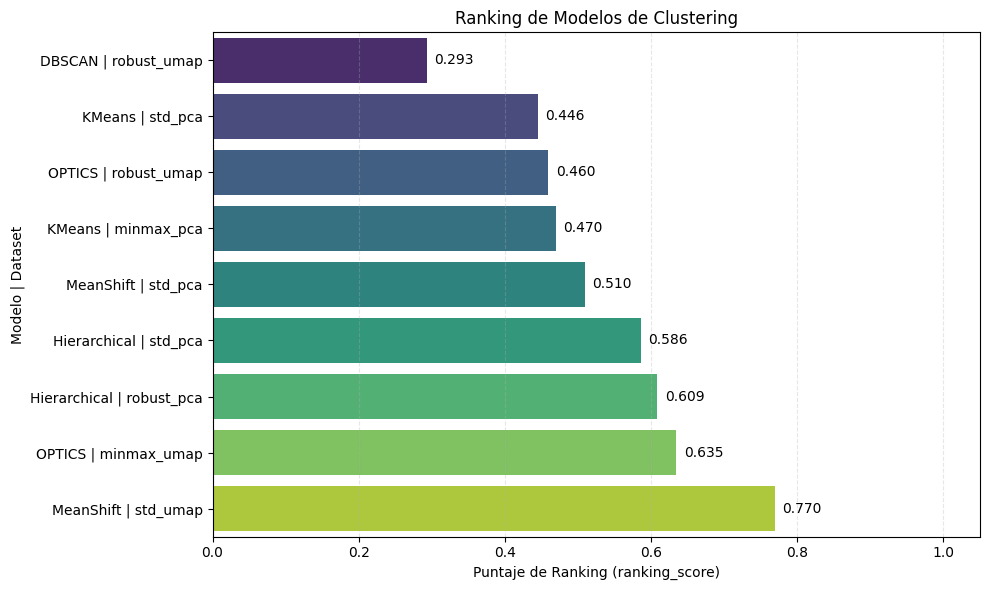

In [7]:
# Cargamos los resultados
ranking_df = pd.read_csv("../models/clustering/ranking_modelos.csv")

# Asegurarse de que no haya NaNs
plot_df = ranking_df.dropna(subset=['ranking_score']).copy()

# Ordenar por ranking_score
plot_df = plot_df.sort_values(by='ranking_score', ascending=True)

# Crear columna legible para etiquetas
plot_df['label'] = plot_df['model_name'] + ' | ' + plot_df['model']

# Tamaño del gráfico
plt.figure(figsize=(10, 6))

# Gráfico de barras horizontal
sns.barplot(
    x='ranking_score',
    y='label',
    data=plot_df,
    palette='viridis'
)

# Añadir valores
for i, (score, label) in enumerate(zip(plot_df['ranking_score'], plot_df['label'])):
    plt.text(score + 0.01, i, f"{score:.3f}", va='center')

# Títulos y etiquetas
plt.title('Ranking de Modelos de Clustering')
plt.xlabel('Puntaje de Ranking (ranking_score)')
plt.ylabel('Modelo | Dataset')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

## Interpretación Detallada de Resultados

### Metodología

Se evaluaron múltiples modelos de clustering (`KMeans`, `Hierarchical`, `MeanShift`, `DBSCAN`, `OPTICS`) utilizando distintas representaciones de los datos (`PCA` y `UMAP` sobre versiones estandarizadas, normalizadas y robustas del dataset). Para cada combinación modelo-dataset, se realizó una búsqueda en grid de hiperparámetros y se seleccionó la mejor configuración según el **Silhouette Score**.

Los modelos se evaluaron con las siguientes métricas:

- **Silhouette Score**: mide la coherencia interna de los clusters (mayor es mejor).
- **Davies-Bouldin Index**: mide la dispersión entre clusters (menor es mejor).
- **Calinski-Harabasz Index**: evalúa la separación entre clusters (mayor es mejor).
- **Complejidad computacional**: estimación cualitativa del costo computacional del modelo (menor es mejor).

A partir de estas métricas, se construyó un **ranking compuesto** con la siguiente ponderación:

- `Silhouette Score`: 40%
- `Davies-Bouldin` (invertido): 20%
- `Calinski-Harabasz`: 30%
- `Complejidad`: 10%

---

### Análisis y Conclusiones

- **Mejor Modelo Global**: `MeanShift` sobre `std_umap` obtuvo el mejor score general, con un **balance óptimo entre cohesión y separación**, aunque a un costo computacional alto.
- **Mayor Silhouette**: `OPTICS` sobre `minmax_umap` obtuvo el mayor `Silhouette Score` (**0.72**), lo que indica **alta calidad de clustering**, aunque con menor eficiencia computacional.
- **Modelos Balanceados**: Las dos variantes de `Hierarchical` ofrecen un **buen compromiso entre calidad y complejidad**, con métricas estables y menor costo.
- **Modelos menos efectivos**: `DBSCAN` y `MeanShift` sobre `robust_umap` o `minmax_umap` no lograron identificar clusters válidos, y sus métricas son descartables.
- **KMeans**, aunque eficiente computacionalmente, obtuvo resultados modestos en cuanto a calidad de los clusters, según las métricas.

---

### Recomendaciones

- Si el **rendimiento computacional no es un problema**, usar `MeanShift` con `UMAP` estandarizado como primera opción.
- Para casos donde la **eficiencia importa**, `Hierarchical` con `PCA` es una excelente alternativa.
- Evitar combinaciones que consistentemente no entregan clusters válidos (`DBSCAN` en algunos casos de UMAP).

## Guardado de los 3 mejores modelos

In [ ]:
# Crear carpeta si no existe aun
save_path = "../models/clustering/"
os.makedirs(save_path, exist_ok=True)

# Guardar los 3 mejores modelos
top_3 = ranking_df.head(3)

for idx, row in top_3.iterrows():
    model_key = f"{row['model_name']} | {row['model']}"
    model_instance = best_models.get(model_key)
    
    if model_instance is not None:
        filename = f"{row['model_name']}-{row['model']}.pkl".replace(" ", "_")
        filepath = os.path.join(save_path, filename)
        joblib.dump(model_instance, filepath)
        print(f"Guardado: {filepath}")
    else:
        print(f"No se encontró el modelo para: {model_key}")

Guardado: ../models/clustering/MeanShift-std_umap.pkl
Guardado: ../models/clustering/OPTICS-minmax_umap.pkl
Guardado: ../models/clustering/Hierarchical-robust_pca.pkl
